# Trabalho Computacional 02: Modelagem e Simulação de um Alto-Falante
**Disciplina:** Modelagem e Simulação Multifísica

Este notebook contém a resolução das Atividades 1 a 4 do Trabalho Computacional 2. 

---

### Atividade 1.1: Modelo Linear com Sinal de Áudio Real

Nesta primeira etapa, simulamos o modelo linear do alto-falante usando como entrada o áudio gravado. Assumimos que o fator de força magnética ($Bl$) é constante e igual a $Bl_0$. O sinal foi escalado para um pico de 1,8 V, ficando dentro do limite de tensão pedido

O modelo é regido pelas seguintes equações (Elétrica e Mecânica):
$$ \frac{di}{dt} = \frac{1}{L} \left( V_{in}(t) - R \cdot i - Bl_0 \cdot v \right) $$
$$ \frac{dx}{dt} = v $$
$$ \frac{dv}{dt} = \ddot{x} = \frac{1}{m} \left( Bl_0 \cdot i - k \cdot x - b \cdot v \right) $$

Simulando o modelo linear. Aguarde...
Excursão máxima do cone no modelo linear: 4.351400e-04 m


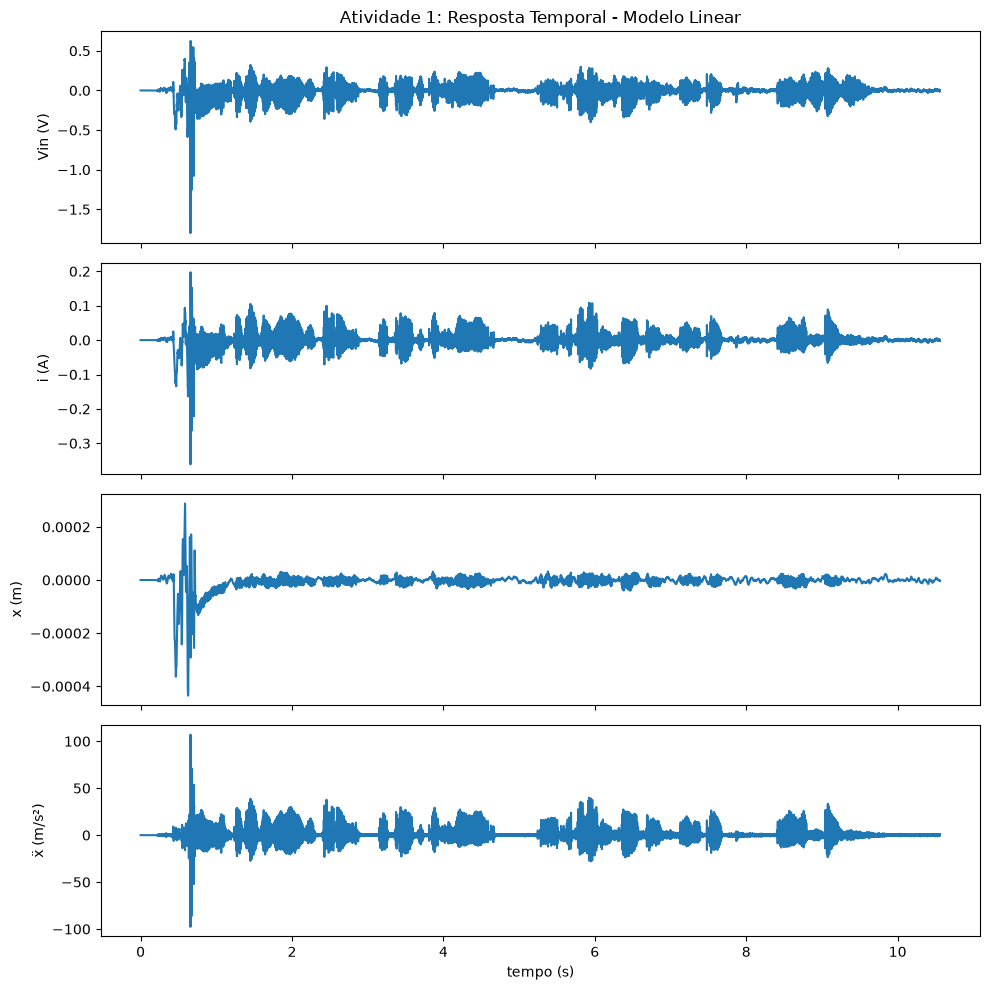

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

# --- Parâmetros físicos do alto-falante ---
m = 14.35e-3   # Massa (kg)
b = 0.786      # Amortecimento (N.s/m)
k = 1852       # Rigidez (N/m)
Bl0 = 4.95     # Fator de força linear (N/A)
L = 266e-6     # Indutância (H)
R = 3.3        # Resistência (Ohms)

# --- Configuração de Pastas ---
pasta_script = os.getcwd()
pasta_saida = os.path.join(pasta_script, "resultados")
os.makedirs(pasta_saida, exist_ok=True)

# --- Leitura do Áudio de Entrada ---
caminho_audio = os.path.join(pasta_script, "TC02-in.wav")
fs, audio = wavfile.read(caminho_audio)

if audio.ndim > 1:
    audio = audio[:, 0] # Converte para mono se for estéreo

audio = audio.astype(np.float64)
audio = audio / np.max(np.abs(audio))

V_PICO = 1.8
Vin_amostras = V_PICO * audio
t_audio = np.arange(len(Vin_amostras)) / fs

u_interp = interp1d(t_audio, Vin_amostras, bounds_error=False, fill_value=0.0)

# --- Definição das Derivadas (Modelo Linear) ---
def derivadas_linear(t, z):
    i, x, v = z
    u = u_interp(t)
    
    di_dt = -(R/L)*i - (Bl0/L)*v + u/L
    dx_dt = v
    dv_dt = (Bl0/m)*i - (k/m)*x - (b/m)*v
    
    return [di_dt, dx_dt, dv_dt]

# --- Simulação Linear ---
print("Simulando o modelo linear. Aguarde...")
z0 = [0.0, 0.0, 0.0]
t_span = (t_audio[0], t_audio[-1])

sol_linear = solve_ivp(derivadas_linear, t_span, z0, t_eval=t_audio, method="RK45", max_step=1/fs)

i_lin = sol_linear.y[0]
x_lin = sol_linear.y[1]
v_lin = sol_linear.y[2]

# Cálculo da aceleração linear
a_lin = (Bl0/m)*i_lin - (k/m)*x_lin - (b/m)*v_lin

# Excursão máxima (será usada na Atividade 2)
x_max_linear = np.max(np.abs(x_lin))
print(f"Excursão máxima do cone no modelo linear: {x_max_linear:.6e} m")

# --- Gráficos no Domínio do Tempo ---
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
axs[0].plot(t_audio, Vin_amostras); axs[0].set_ylabel("Vin (V)")
axs[0].set_title("Atividade 1: Resposta Temporal - Modelo Linear")
axs[1].plot(t_audio, i_lin);        axs[1].set_ylabel("i (A)")
axs[2].plot(t_audio, x_lin);        axs[2].set_ylabel("x (m)")
axs[3].plot(t_audio, a_lin);        axs[3].set_ylabel("ẍ (m/s²)")
axs[3].set_xlabel("tempo (s)")
plt.tight_layout()
plt.show()

### Atividade 1.2: Análise em Frequência e Áudio

Agora é calculada a Transformada de Fourier para a entrada ($V_{in}$) e para a saída ($\ddot{x}$). Também é calculada a Função de Resposta em Frequência (FRF) teórica do sistema. A resposta em aceleração é salva no arquivo `TC02-out1.wav`.

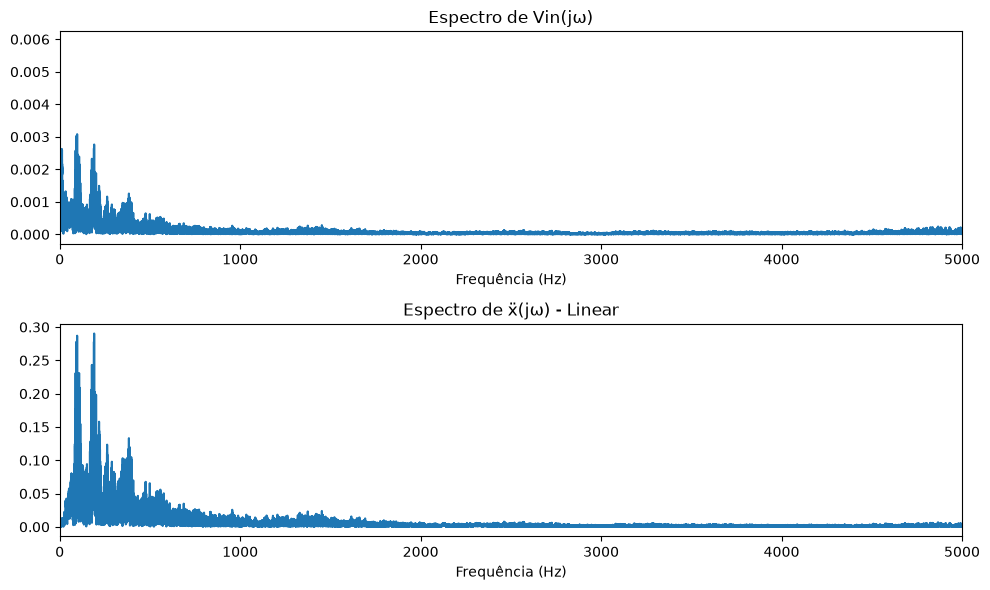

Áudio linear salvo como TC02-out1.wav


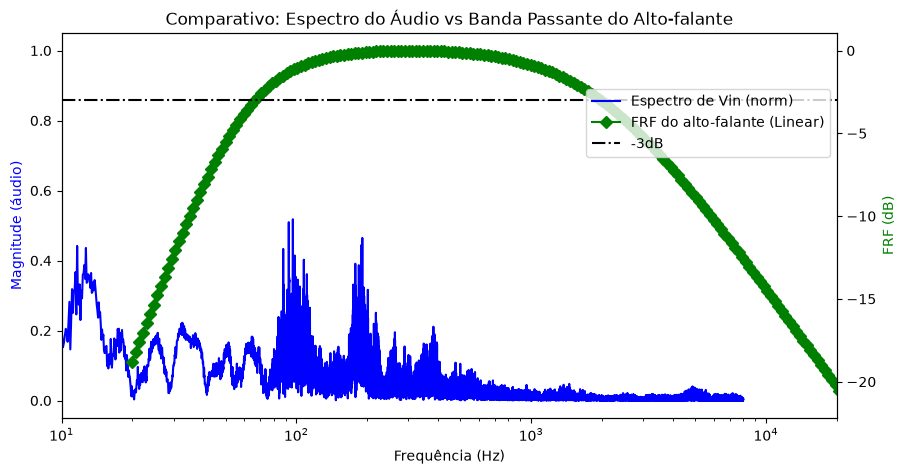

In [10]:
def espectro(sinal, fs):
    N = len(sinal)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    mag = np.abs(np.fft.rfft(sinal)) / N
    return freqs, mag

f_vin, mag_vin = espectro(Vin_amostras, fs)
f_a_lin, mag_a_lin = espectro(a_lin, fs)

# --- Gráficos dos Espectros ---
fig, axs = plt.subplots(2, 1, figsize=(10, 6))
axs[0].plot(f_vin, mag_vin); axs[0].set_title("Espectro de Vin(jω)")
axs[0].set_xlim(0, 5000)
axs[1].plot(f_a_lin, mag_a_lin); axs[1].set_title("Espectro de ẍ(jω) - Linear")
axs[1].set_xlim(0, 5000)
for ax in axs:
    ax.set_xlabel("Frequência (Hz)")
plt.tight_layout()
plt.show()

# --- Salvar o áudio TC02-out1.wav ---
a_norm = a_lin / np.max(np.abs(a_lin))
a_int16 = (a_norm * 32767).astype(np.int16)
wavfile.write(os.path.join(pasta_saida, "TC02-out1.wav"), fs, a_int16)
print("Áudio linear salvo como TC02-out1.wav")

# --- Cálculo da FRF (Espaço de Estados) ---
fmin, fmax, npoints = 20, 22e3, 200
f_frf = np.logspace(np.log10(fmin), np.log10(fmax), npoints)
omega = 2 * np.pi * f_frf

A_lin = np.array([[-R/L, 0, -Bl0/L], [0, 0, 1], [Bl0/m, -k/m, -b/m]])
B_lin = np.array([1/L, 0, 0])
C_lin = np.array([0, 0, 1])
I3 = np.eye(3)

G = 1j * np.zeros(npoints)
for idx in range(npoints):
    aux = np.linalg.inv(1j*omega[idx]*I3 - A_lin)
    G[idx] = C_lin.dot(aux.dot(B_lin))

FRF = 20*np.log10(np.abs(1j*omega*G))
FRF = FRF - np.max(FRF)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.semilogx(f_vin, mag_vin / np.max(mag_vin), 'b', label="Espectro de Vin (norm)")
ax1.set_xlabel("Frequência (Hz)")
ax1.set_ylabel("Magnitude (áudio)", color='b')
ax1.set_xlim(10, 2e4)

ax2 = ax1.twinx()
ax2.semilogx(f_frf, FRF, 'g-D', label="FRF do alto-falante (Linear)")
ax2.axhline(-3, color='k', linestyle='-.', label="-3dB")
ax2.set_ylabel("FRF (dB)", color='g')
fig.legend(loc="center right", bbox_to_anchor=(0.9, 0.7))
plt.title("Comparativo: Espectro do Áudio vs Banda Passante do Alto-falante")
plt.show()

---
## Atividade 2: Modelo Não Linear do Fator de Força 𝐵𝑙(𝑥)

Na vida real, a bobina móvel pode sair da região de campo magnético uniforme. Portanto, $Bl$ diminui quando o deslocamento $|x|$ aumenta. 
A excursão máxima encontrada no modelo linear (`x_max_linear`) é portanto utilizada para criar o fator de decaimento polinomial de segunda ordem:

* $x_1 = 0.75 \times x_{max\_linear}$
* $x_2 = 1.50 \times x_{max\_linear}$

$$
Bl(x) = 
\begin{cases} 
Bl_0, & \text{se } |x| \le x_1 \\
Bl_0 \left(1 - \frac{|x| - x_1}{x_2 - x_1}\right)^2, & \text{se } x_1 < |x| < x_2 \\
0, & \text{se } |x| \ge x_2 
\end{cases}
$$

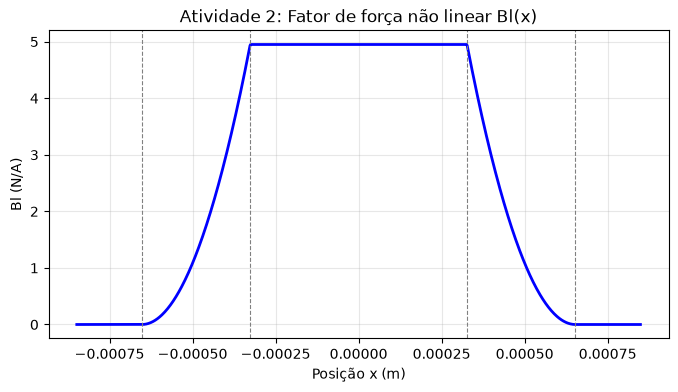

Limites definidos: x1 = 3.2636e-04 m, x2 = 6.5271e-04 m


In [11]:
x1 = 0.75 * x_max_linear
x2 = 1.50 * x_max_linear

def Bl_de_x(x):
    ax = abs(x)
    if ax <= x1:
        return Bl0
    elif ax >= x2:
        return 0.0
    else:
        frac = (ax - x1) / (x2 - x1)
        return Bl0 * (1 - frac)**2

# --- Visualização do fator de força não linear ---
x_vals = np.linspace(-1.3*x2, 1.3*x2, 1000)
Bl_vals = np.array([Bl_de_x(x) for x in x_vals])

plt.figure(figsize=(8, 4))
plt.plot(x_vals, Bl_vals, 'b', linewidth=2)
for xv in [-x2, -x1, x1, x2]:
    plt.axvline(xv, color='gray', linestyle='--', linewidth=0.8)

plt.xlabel("Posição x (m)")
plt.ylabel("Bl (N/A)")
plt.title("Atividade 2: Fator de força não linear Bl(x)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Limites definidos: x1 = {x1:.4e} m, x2 = {x2:.4e} m")

---
## Atividade 3: Simulação do Modelo Não Linear com Sinal de Áudio Real
Agora vamos modificar a função de derivadas para usar `Bl_de_x(x)` e resolver o sistema novamente para o sinal de áudio. Os resultados em aceleração ($\ddot{x}$) serão salvos no arquivo `TC02-out2.wav`.

Simulando o modelo não linear. Aguarde...


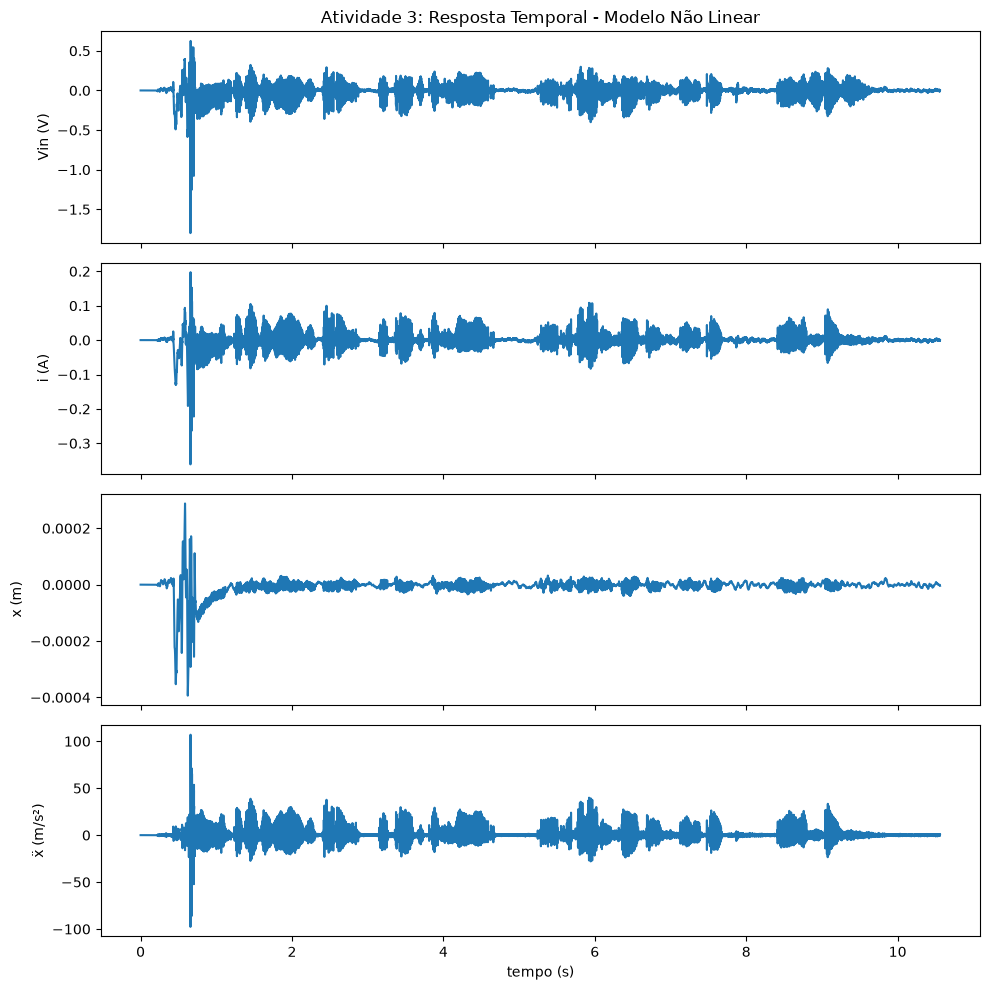

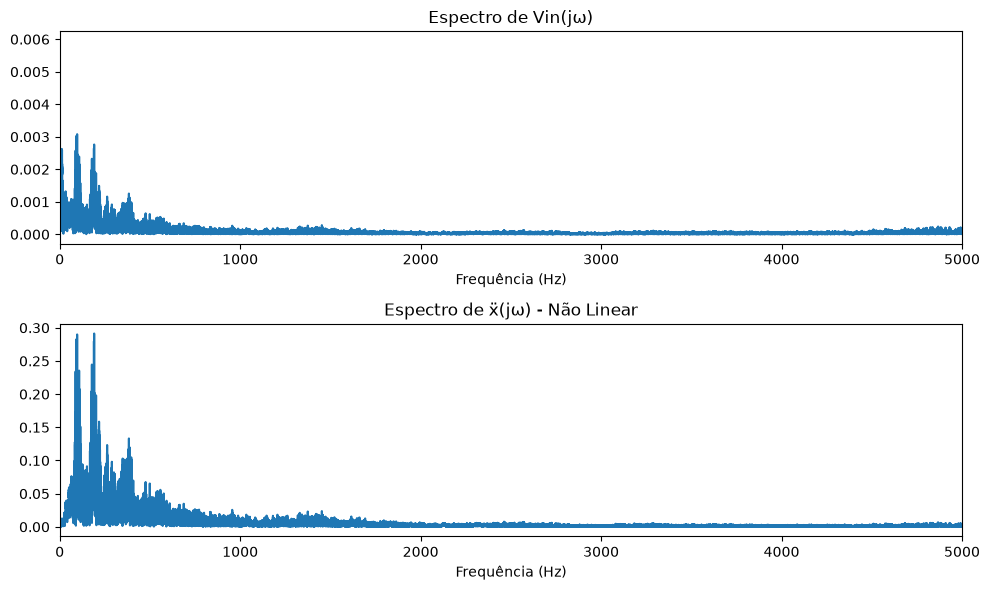

Áudio não linear salvo como TC02-out2.wav


In [12]:
# Definição das derivadas para o modelo não linear
def derivadas_nao_linear(t, z):
    i, x, v = z
    u = u_interp(t)
    Bl = Bl_de_x(x)  # Garante que o fator Bl depende da posição x no instante t
    
    di_dt = -(R/L)*i - (Bl/L)*v + u/L
    dx_dt = v
    dv_dt = (Bl/m)*i - (k/m)*x - (b/m)*v
    
    return [di_dt, dx_dt, dv_dt]

print("Simulando o modelo não linear. Aguarde...")
sol_nlin = solve_ivp(derivadas_nao_linear, t_span, z0, t_eval=t_audio, method="RK45", max_step=1/fs)

i_nlin_audio = sol_nlin.y[0]
x_nlin_audio = sol_nlin.y[1]
v_nlin_audio = sol_nlin.y[2]

Bl_vetor_audio = np.array([Bl_de_x(x) for x in x_nlin_audio])
a_nlin_audio = (Bl_vetor_audio/m)*i_nlin_audio - (k/m)*x_nlin_audio - (b/m)*v_nlin_audio

# Gráficos no domínio do tempo
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
axs[0].plot(t_audio, Vin_amostras); axs[0].set_ylabel("Vin (V)")
axs[0].set_title("Atividade 3: Resposta Temporal - Modelo Não Linear")
axs[1].plot(t_audio, i_nlin_audio); axs[1].set_ylabel("i (A)")
axs[2].plot(t_audio, x_nlin_audio); axs[2].set_ylabel("x (m)")
axs[3].plot(t_audio, a_nlin_audio); axs[3].set_ylabel("ẍ (m/s²)")
axs[3].set_xlabel("tempo (s)")
plt.tight_layout()
plt.show()

# Espectro e salvamento 
f_a_nlin, mag_a_nlin = espectro(a_nlin_audio, fs)

fig, axs = plt.subplots(2, 1, figsize=(10, 6))
axs[0].plot(f_vin, mag_vin); axs[0].set_title("Espectro de Vin(jω)")
axs[0].set_xlim(0, 5000)
axs[1].plot(f_a_nlin, mag_a_nlin); axs[1].set_title("Espectro de ẍ(jω) - Não Linear")
axs[1].set_xlim(0, 5000)
for ax in axs: ax.set_xlabel("Frequência (Hz)")
plt.tight_layout()
plt.show()

# Salvamento da onda de saída
a_norm_nlin = a_nlin_audio / np.max(np.abs(a_nlin_audio))
a_int16_nlin = (a_norm_nlin * 32767).astype(np.int16)
wavfile.write(os.path.join(pasta_saida, "TC02-out2.wav"), fs, a_int16_nlin)
print("Áudio não linear salvo como TC02-out2.wav")

---
## Atividade 4.1: Resposta a um Sinal Senoidal

Para observar com clareza o efeito das não linearidades (distorção harmônica e dinâmica de repouso), vamos aplicar um sinal senoidal puro.

**Parâmetros do Sinal:**
* Frequência: 150 Hz (faixa de fonação da voz humana)
* Amplitude: 2V (4Vpp)
* Duração: 30 períodos (> 20 períodos, conforme pedido)

Simulando regime com senoide (Linear e Não Linear)...


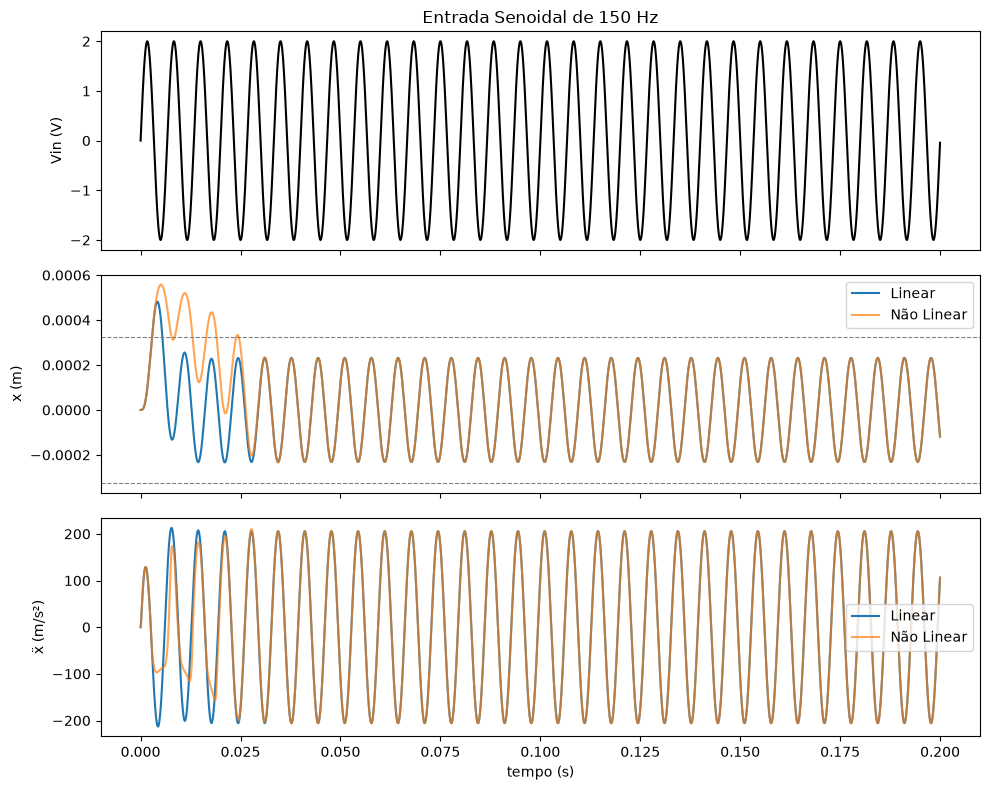

In [13]:
# --- Criação do Sinal Senoidal ---
freq_sinal = 150
amplitude = 2.0
n_periodos = 30
fs_seno = 44100
duracao = n_periodos / freq_sinal

t_seno = np.arange(0, duracao, 1/fs_seno)
Vin_seno = amplitude * np.sin(2*np.pi*freq_sinal*t_seno)

u_seno_interp = interp1d(t_seno, Vin_seno, bounds_error=False, fill_value=0.0)

# Função auxiliar unificada para a EDO senoidal
def derivadas_senoidal(t, z, nao_linear):
    i, x, v = z
    u = u_seno_interp(t)
    Bl = Bl_de_x(x) if nao_linear else Bl0
    
    di_dt = -(R/L)*i - (Bl/L)*v + u/L
    dx_dt = v
    dv_dt = (Bl/m)*i - (k/m)*x - (b/m)*v
    return [di_dt, dx_dt, dv_dt]

t_span_seno = (t_seno[0], t_seno[-1])

print("Simulando regime com senoide (Linear e Não Linear)...")
sol_lin_seno = solve_ivp(derivadas_senoidal, t_span_seno, z0, args=(False,), t_eval=t_seno, method="RK45", max_step=1/fs_seno)
sol_nlin_seno = solve_ivp(derivadas_senoidal, t_span_seno, z0, args=(True,), t_eval=t_seno, method="RK45", max_step=1/fs_seno)

def calc_acc_seno(sol, nao_linear):
    i_t, x_t, v_t = sol.y[0], sol.y[1], sol.y[2]
    Bl_vetor = np.array([Bl_de_x(x) if nao_linear else Bl0 for x in x_t])
    a_t = (Bl_vetor/m)*i_t - (k/m)*x_t - (b/m)*v_t
    return x_t, a_t

x_lin_s, a_lin_s = calc_acc_seno(sol_lin_seno, False)
x_nlin_s, a_nlin_s = calc_acc_seno(sol_nlin_seno, True)

# --- Comparação Temporal Global ---
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axs[0].plot(t_seno, Vin_seno, 'k'); axs[0].set_ylabel("Vin (V)")
axs[0].set_title("Entrada Senoidal de 150 Hz")

axs[1].plot(t_seno, x_lin_s, label="Linear")
axs[1].plot(t_seno, x_nlin_s, label="Não Linear", alpha=0.7)
axs[1].axhline(x1, color='gray', linestyle='--', linewidth=0.8)
axs[1].axhline(-x1, color='gray', linestyle='--', linewidth=0.8)
axs[1].set_ylabel("x (m)"); axs[1].legend()

axs[2].plot(t_seno, a_lin_s, label="Linear")
axs[2].plot(t_seno, a_nlin_s, label="Não Linear", alpha=0.7)
axs[2].set_ylabel("ẍ (m/s²)"); axs[2].set_xlabel("tempo (s)"); axs[2].legend()

plt.tight_layout()
plt.show()

## Atividade 4.2: Análise dos Regimes Transitório, Permanente e Distorção

O decréscimo do $Bl$ nas extremidades da excursão do cone resulta em um achatamento da onda, que no domínio da frequência se manifesta como o surgimento de **distorções harmônicas** (múltiplos de 150Hz).

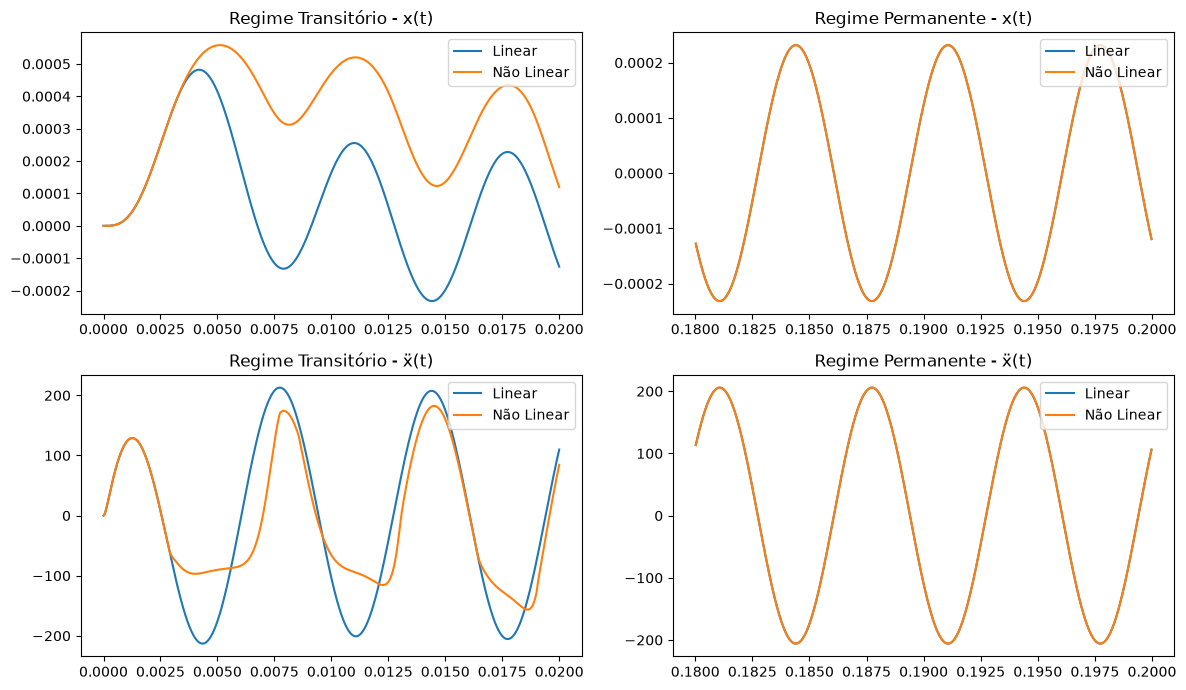

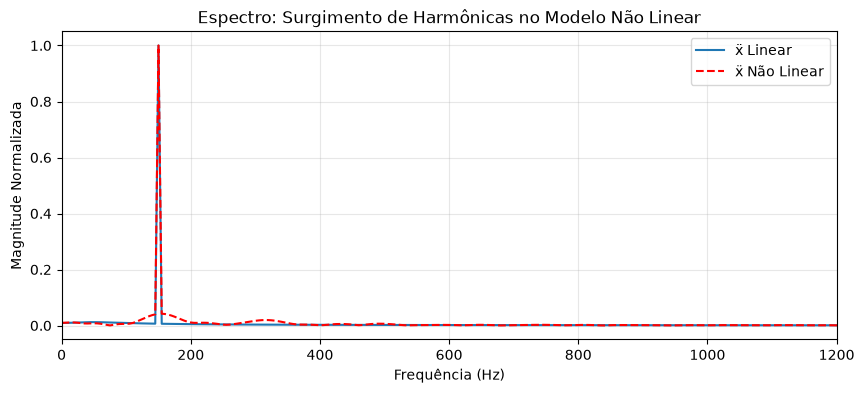

In [14]:
# --- Zooms nos regimes ---
t_limite_transitorio = 3 / freq_sinal # primeiros 3 periodos
t_limite_permanente = duracao - (3 / freq_sinal) # ultimos 3 periodos

mask_trans = (t_seno <= t_limite_transitorio)
mask_perm = (t_seno >= t_limite_permanente)

fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Transitório
axs[0,0].plot(t_seno[mask_trans], x_lin_s[mask_trans], label="Linear")
axs[0,0].plot(t_seno[mask_trans], x_nlin_s[mask_trans], label="Não Linear")
axs[0,0].set_title("Regime Transitório - x(t)")

axs[1,0].plot(t_seno[mask_trans], a_lin_s[mask_trans], label="Linear")
axs[1,0].plot(t_seno[mask_trans], a_nlin_s[mask_trans], label="Não Linear")
axs[1,0].set_title("Regime Transitório - ẍ(t)")

# Permanente
axs[0,1].plot(t_seno[mask_perm], x_lin_s[mask_perm], label="Linear")
axs[0,1].plot(t_seno[mask_perm], x_nlin_s[mask_perm], label="Não Linear")
axs[0,1].set_title("Regime Permanente - x(t)")

axs[1,1].plot(t_seno[mask_perm], a_lin_s[mask_perm], label="Linear")
axs[1,1].plot(t_seno[mask_perm], a_nlin_s[mask_perm], label="Não Linear")
axs[1,1].set_title("Regime Permanente - ẍ(t)")

for ax in axs.flat:
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# --- Análise do Espectro de Aceleração (Distorção Harmônica) ---
f_lin_fft, mag_lin_fft = espectro(a_lin_s, fs_seno)
f_nlin_fft, mag_nlin_fft = espectro(a_nlin_s, fs_seno)

plt.figure(figsize=(10, 4))
plt.plot(f_lin_fft, mag_lin_fft / np.max(mag_lin_fft), label="ẍ Linear")
plt.plot(f_nlin_fft, mag_nlin_fft / np.max(mag_nlin_fft), '--', color='red', label="ẍ Não Linear")
plt.xlim(0, 8 * freq_sinal) # Visualizando até a 8ª harmônica
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude Normalizada")
plt.title("Espectro: Surgimento de Harmônicas no Modelo Não Linear")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()